# Quantum vs Classical STFT — Exploratory Notebook

Walk through a single signal end-to-end: generate, run both STFTs, compare magnitudes and phases, visualize a few of the matrix views, and sweep windows. Uses `src.*` — run from the repo root.

In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.config import set_global_seed
from src.signals import chirp_signal, sine, sum_of_sines, speech_like
from src.stft_classical import stft_custom
from src.stft_quantum import stft_quantum
from src.metrics import mse, cosine_similarity_flat, phase_error_stats, spectrogram_difference, gram_matrix
from src.matrices import dft_matrix, unitary_dft_matrix, toeplitz_conv_matrix, window

set_global_seed(1234)

## 1. Generate a signal and run both STFTs

In [2]:
fs = 16000
t, x = chirp_signal(f0=200, f1=4000, duration=0.5, fs=fs)

frame_len, hop = 256, 128
Zc, freqs, times = stft_custom(x, frame_len, hop, 'hann', fs=fs)
Zq, _, _      = stft_quantum(x, frame_len, hop, 'hann', fs=fs)

print('classical shape:', Zc.shape)
print('quantum   shape:', Zq.shape)
print('MSE:', mse(Zc, Zq))
print('cosine:', cosine_similarity_flat(Zc, Zq))
print('phase stats:', phase_error_stats(Zc, Zq))

classical shape: (61, 256)
quantum   shape: (61, 256)
MSE: 1.865035209916089e-30
cosine: 1.0
phase stats: {'mean': 1.0548662922213504e-12, 'median': 0.0, 'std': 1.0857871514290636e-10, 'n_valid': 15616}


## 2. Side-by-side spectrograms + difference

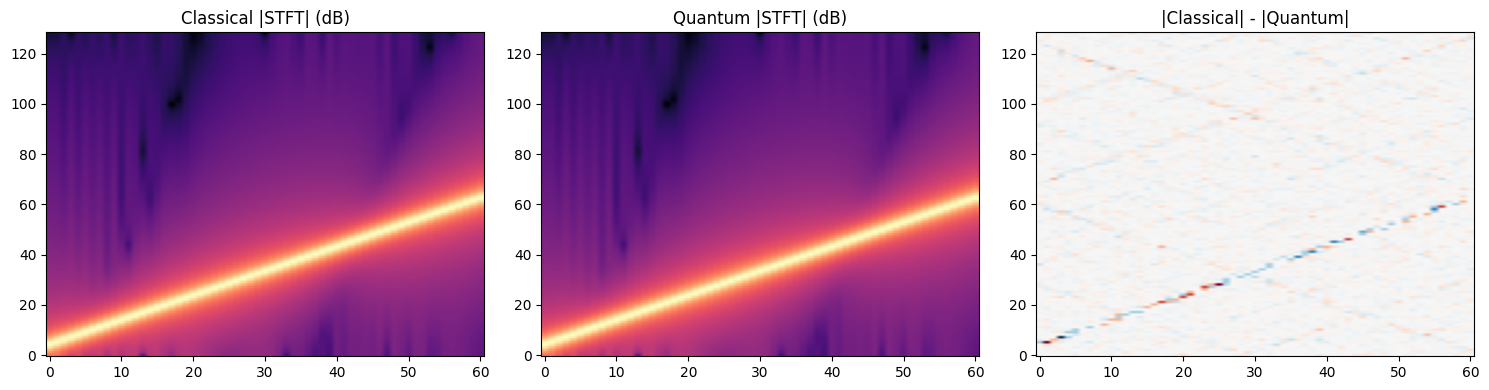

In [3]:
def _to_db(S):
    half = S.shape[1] // 2 + 1
    return 20.0 * np.log10(np.abs(S[:, :half]).T + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(_to_db(Zc), origin='lower', aspect='auto', cmap='magma')
axes[0].set_title('Classical |STFT| (dB)')
axes[1].imshow(_to_db(Zq), origin='lower', aspect='auto', cmap='magma')
axes[1].set_title('Quantum |STFT| (dB)')
diff = spectrogram_difference(Zc, Zq)['magnitude']
vmax = np.max(np.abs(diff)) or 1.0
axes[2].imshow(diff.T[:diff.shape[1]//2 + 1], origin='lower', aspect='auto',
               cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[2].set_title('|Classical| - |Quantum|')
plt.tight_layout(); plt.show()

## 3. Window comparison

Quantum vs classical MSE across the four supported windows — they should all be machine-precision zero because both pipelines reduce to the same FFT when `n_fft` is a power of two.

In [4]:
for wname in ['rect', 'hann', 'hamming', 'blackman']:
    Zc, _, _ = stft_custom(x, frame_len, hop, wname, fs=fs)
    Zq, _, _ = stft_quantum(x, frame_len, hop, wname, fs=fs)
    print(f'{wname:10s}  mse={mse(Zc, Zq):.3e}  cos={cosine_similarity_flat(Zc, Zq):.6f}')

rect        mse=5.423e-30  cos=1.000000
hann        mse=1.865e-30  cos=1.000000
hamming     mse=2.038e-30  cos=1.000000
blackman    mse=1.625e-30  cos=1.000000


## 4. Matrix views — DFT, unitary DFT, Gram, Toeplitz

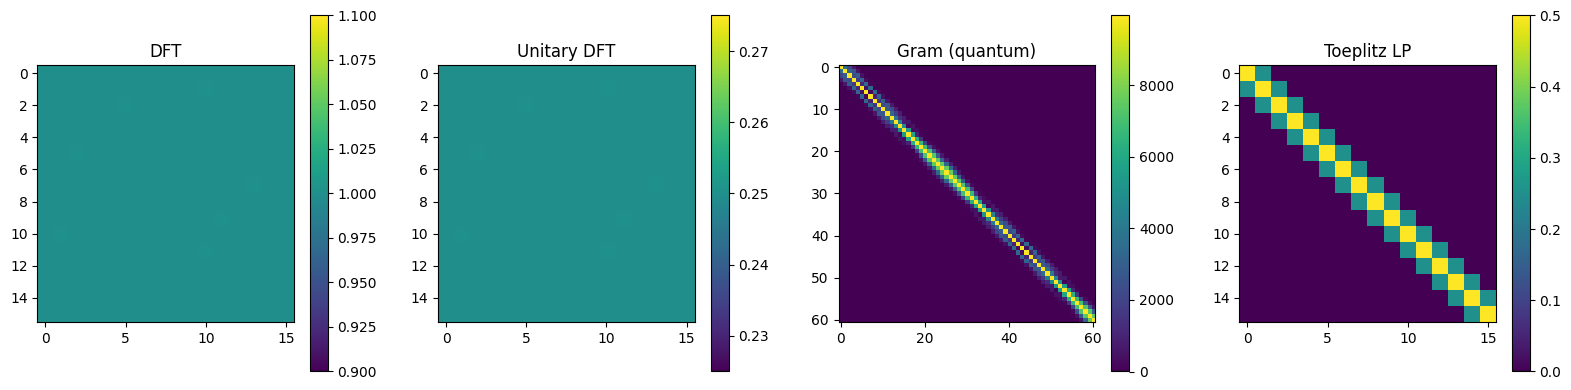

Algebraic check ||U - D/sqrt(N)||_inf = 0.0


In [ ]:
N = 16
D = dft_matrix(N)
U = unitary_dft_matrix(N)
G = gram_matrix(Zq)  # coefficient-frame Gram (quantum)
T = toeplitz_conv_matrix(np.array([0.25, 0.5, 0.25]), N, mode='same')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, M, title in zip(axes, [D, U, G, T], ['DFT', 'Unitary DFT', 'Gram (quantum)', 'Toeplitz LP']):
    data = np.abs(M)
    im = ax.imshow(data, cmap='viridis')
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

print('Algebraic check ||U - D/sqrt(N)||_inf =', np.max(np.abs(U - D / np.sqrt(N))))

## 5. Takeaway

When `n_fft` is a power of two, the quantum-inspired pipeline's output coefficients are equal (to floating-point error) to the classical windowed FFT — because the QFT is literally `D / √N`, and our rescaling multiplies back by `√N`. The interesting divergences appear when `n_fft` is not a power of two (the quantum pipeline forces zero-padding up to the next power of two, producing a different bin grid) or under different windows/hop sizes, which the full experiment grid explores.